# Historical Average Price Model

This notebook provides an overview of the `HistoricalAveragePriceModel` class, which calculates the average prices for the last week and the prices for a given date. The data used in this model is provided by the `CSVDataProvider` class, which reads data from a CSV file.

At present the data available ranges from 2014-12-31T23:00:00Z to 2020-09-30T23:00:00Z.

In [1]:
# Import necessary libraries
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import datetime
sns.set_theme()

module_path = os.path.abspath(os.path.join('../../'))

if module_path not in sys.path:
    sys.path.append(module_path)

from scripts.price_models import HistoricalAveragePriceModel
from scripts.shared import CSVDataProvider
IMAGE_SAVING_LOCATION = os.path.join(module_path, 'images','notebook','price_models')
%matplotlib inline

/Users/akhilesh.koul/Documents/GitHub/OpenEnergy/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Loading

First, we need to load the data. We use the `CSVDataProvider` class to read the data from a CSV file.

In [2]:
csv_file_path = os.path.join(module_path, "data", "time_series", "time_series_60min_singleindex_filtered.csv")
data_provider = CSVDataProvider(csv_file_path)
data = data_provider.get_data(column_names=["GB_GBN_price_day_ahead"],timestamp_column="utc_timestamp")

## Exploratory Data Analysis (EDA)

Let's explore the data to understand its structure and content.

In [3]:
# Display the first few rows of the data
price_data = data[['GB_GBN_price_day_ahead']]
print(price_data.head())

# Display the data types of each column
print(price_data.dtypes)

# Display the number of missing values in each column
print(price_data.isna().sum())

                           GB_GBN_price_day_ahead
2014-12-31 23:00:00+00:00                     NaN
2015-01-01 00:00:00+00:00                     NaN
2015-01-01 01:00:00+00:00                     NaN
2015-01-01 02:00:00+00:00                     NaN
2015-01-01 03:00:00+00:00                     NaN
GB_GBN_price_day_ahead    float64
dtype: object
GB_GBN_price_day_ahead    111
dtype: int64


## Data Visualization

Let's visualize the data to gain more insights.

### Distribution of GB_GBN_price_day_ahead

This plot shows the distribution of 'GB_GBN_price_day_ahead'. The histogram represents the frequency of different price levels, and the line represents the kernel density estimate.

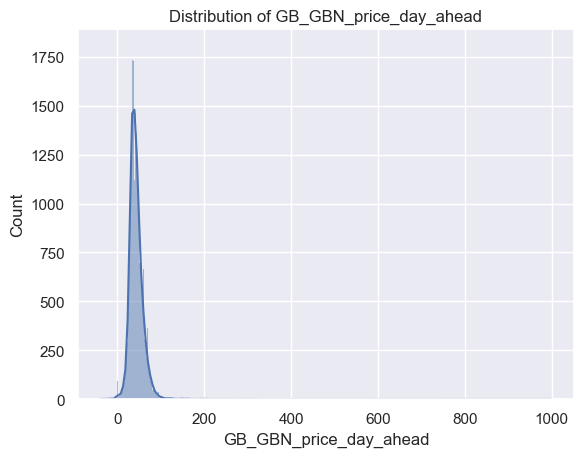

In [4]:
# Plot the distribution of 'GB_GBN_price_day_ahead'
sns.histplot(data['GB_GBN_price_day_ahead'].dropna(), kde=True)
plt.title('Distribution of GB_GBN_price_day_ahead')
plt.savefig(os.path.join(IMAGE_SAVING_LOCATION, 'Distribution_of_GB_GBN_price_day_ahead.png'))
plt.show()


### GB_GBN_price_day_ahead over Time

This plot shows 'GB_GBN_price_day_ahead' over time. The line represents the price at different points in time.

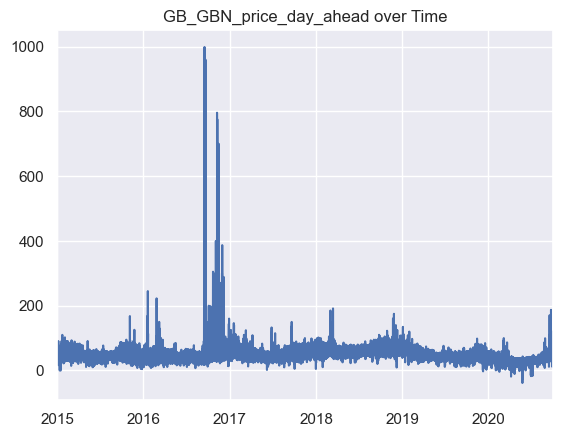

In [5]:
# Plot the 'GB_GBN_price_day_ahead' over time
data['GB_GBN_price_day_ahead'].plot()
plt.title('GB_GBN_price_day_ahead over Time')
plt.savefig(os.path.join(IMAGE_SAVING_LOCATION, 'GB_GBN_price_day_ahead_over_Time.png'))
plt.show()

### Mean and Standard Deviation of GB_GBN_price_day_ahead by Hour

This plot shows the mean and standard deviation of 'GB_GBN_price_day_ahead' for each hour of the day. The blue line represents the mean, and the shaded area represents the standard deviation.

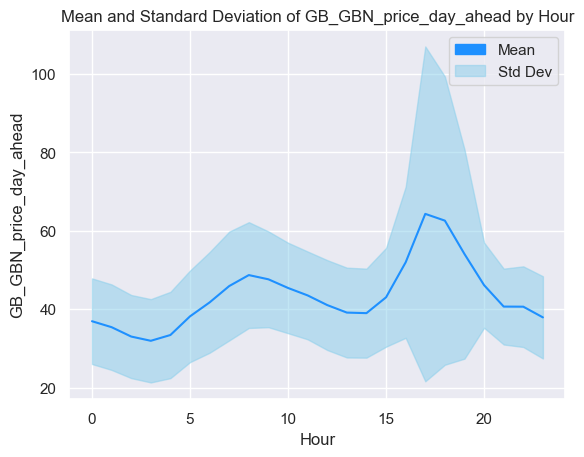

In [6]:

# Extract the hour from the 'utc_timestamp' column
data['hour'] = data.index.hour

# Calculate the mean and standard deviation of 'GB_GBN_price_day_ahead' for each hour
mean_prices = data.groupby('hour')['GB_GBN_price_day_ahead'].mean()
std_prices = data.groupby('hour')['GB_GBN_price_day_ahead'].std()

# Create a new DataFrame for the mean and standard deviation
price_data = pd.DataFrame({'mean': mean_prices, 'std': std_prices})

# Plot the mean and standard deviation
price_data['mean'].plot(color='dodgerblue', label='Mean')
plt.fill_between(price_data.index, price_data['mean'] - price_data['std'], price_data['mean'] + price_data['std'], color='skyblue', alpha=0.5)

# Create a legend for the mean and standard deviation
mean_patch = mpatches.Patch(color='dodgerblue', label='Mean')
std_patch = mpatches.Patch(color='skyblue', alpha=0.5, label='Std Dev')
plt.legend(handles=[mean_patch, std_patch])

plt.title('Mean and Standard Deviation of GB_GBN_price_day_ahead by Hour')
plt.xlabel('Hour')
plt.ylabel('GB_GBN_price_day_ahead')
plt.savefig(os.path.join(IMAGE_SAVING_LOCATION, 'Mean_and_Standard_Deviation_of_GB_GBN_price_day_ahead_by_Hour.png'))
plt.show()

## Historical Average Price Model

Now, let's use the Historical Average Price Model to analyze the data.

In [7]:
model = HistoricalAveragePriceModel(data_provider)
date = datetime.date(2020, 9, 30)  # replace with your date
average_prices_last_week, prices_current_date = model.get_prices(date)

# Display the average prices last week
print(average_prices_last_week)

# Display the prices on the current date
print(prices_current_date)

[30.854285714285716, 27.595714285714283, 25.568571428571428, 28.042857142857144, 35.57857142857143, 44.00571428571429, 49.46, 50.82285714285714, 49.26714285714286, 47.94714285714286, 44.402857142857144, 42.83571428571429, 39.57571428571429, 38.082857142857144, 38.45142857142857, 45.51, 55.94571428571429, 73.19142857142857, 66.91714285714286, 51.62, 43.107142857142854, 36.74, 38.45, 33.90857142857143]
[38.83, 35.33, 35.09, 37.12, 44.02, 52.21, 64.05, 58.27, 48.88, 46.33, 43.57, 42.0, 39.91, 40.04, 43.7, 50.12, 56.82, 67.72, 59.49, 46.55, 40.95, 34.84, 37.44, 37.44]


/Users/akhilesh.koul/Documents/GitHub/OpenEnergy/scripts/price_models/average_price_model.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.data[self.PRICE_COLUMN].interpolate(method="linear", inplace=True)


# Conclusion

In this notebook, we explored the `HistoricalAveragePriceModel` class and its dependencies. We performed some basic EDA on our data and used the `HistoricalAveragePriceModel` class to calculate the average prices for the last week and the prices for a given date.